# Introduction to pandas

In [1]:
# Introduction to pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas'

In [2]:
# Loading the data
df = pd.read_csv("dirty_cafe_sales.csv")

In [3]:
# first few rows of the data
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [4]:
# Undertanding the data
df.shape

(10000, 8)

### 10,000 rows and 8 columns

In [5]:
# undersnding the columns
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [6]:
# data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [7]:
# Summary statistics
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### Data Audit
## Checking missing values

In [8]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [9]:
# checking missing values
df.isnull().sum().sum()

np.int64(6826)

In [10]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
# take a sample of the data
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2851,TXN_6889867,Sandwich,5,4.0,20.0,Cash,NaN,2023-03-07
5833,TXN_5061600,Juice,3,3.0,UNKNOWN,NaN,In-store,2023-11-23
7268,TXN_8103754,Salad,5,5.0,25.0,Cash,Takeaway,2023-01-29
7408,TXN_6344806,Juice,3,3.0,9.0,Credit Card,NaN,2023-05-08
8701,TXN_8014289,Juice,5,3.0,15.0,Digital Wallet,In-store,2023-12-04
2192,TXN_5413274,Smoothie,5,4.0,20.0,Credit Card,In-store,2023-02-10
7287,TXN_1830432,Cookie,3,1.0,3.0,Digital Wallet,Takeaway,2023-11-02
2197,TXN_8900579,Sandwich,3,4.0,12.0,Credit Card,NaN,2023-11-01
2678,TXN_9202496,Cake,5,3.0,15.0,Credit Card,In-store,2023-07-19
48,TXN_8201146,Juice,5,3.0,15.0,Cash,NaN,2023-06-26


# Data cleaning, the order matters
1 Handle hidden errors e.g unknowns, Errors,
2 Deal with incorrect data types
3 Handle the missing values

In [12]:
# Identify error and unknown strings
invalid_values = ['ERROR', 'UNKNOWN','N/A']
cols_with_invalid = df.columns[df.isin(invalid_values).any()].tolist()
print(cols_with_invalid)

['Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [13]:
# Now remove them n/b replace with NaN
df.replace(invalid_values, np.nan, inplace=True)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [14]:
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
6860,TXN_9168898,Juice,2,3.0,6.0,Cash,Takeaway,2023-09-28
4021,TXN_6424202,Cookie,2,NaN,NaN,Credit Card,In-store,2023-11-20
8069,TXN_2259102,Sandwich,2,4.0,NaN,NaN,NaN,2023-02-19
8850,TXN_2575160,Tea,5,1.5,7.5,NaN,NaN,2023-01-02
1051,TXN_3616362,Smoothie,5,4.0,NaN,Digital Wallet,In-store,2023-12-02
8382,TXN_4030763,Salad,2,5.0,10.0,NaN,Takeaway,2023-06-17
7574,TXN_6223157,Salad,1,5.0,5.0,NaN,Takeaway,2023-09-13
9277,TXN_7771516,Sandwich,3,4.0,12.0,NaN,NaN,2023-05-26
4510,TXN_6359281,Coffee,2,2.0,4.0,Credit Card,NaN,2023-09-16
7768,TXN_4205860,Salad,5,5.0,25.0,NaN,NaN,2023-09-10


In [15]:
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [16]:
# Recheck for missing values
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [17]:
# fix data types
df['Quantity'] = pd.to_numeric(df['Quantity'], errors = 'coerce')
df ['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors = 'coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors = 'coerce')
   

In [18]:
# convert transaction date to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors = 'coerce')


In [19]:
# clean the text data remove inconsistencies
df['Item'] = df['Item'].str.strip().str.title()
df['Payment Method'] = df['Payment Method'].str.strip().str.title()

In [20]:
# fill missing numerical values
df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Total Spent'].fillna(df['Total Spent'].median())



0        4.0
1       12.0
2        8.0
3       10.0
4        4.0
        ... 
9995     4.0
9996     3.0
9997     8.0
9998     3.0
9999    12.0
Name: Total Spent, Length: 10000, dtype: float64

In [21]:
df.shape

(10000, 8)

In [22]:
#recheck for missing vlaues
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [23]:
# fill the categorical 
df['Location']= df['Location'].fillna('Unknown')

In [24]:
# Dropping missing values
df.dropna(inplace = True)

In [25]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [26]:
df.shape

(5059, 8)

# Exploratory Data Analysis

In [27]:
# Overall sales summary
print('Total Sales: ', df['Total Spent'].sum())
print('Average Sales: ', df['Total Spent'].mean())
print('Max Sales: ', df['Total Spent'].max())


Total Sales:  45473.0
Average Sales:  8.988535283652896
Max Sales:  25.0


In [28]:
# Grouping by product
df.groupby('Item')['Total Spent'].sum().sort_values(ascending = False)

Item
Salad       10090.0
Smoothie     7508.0
Sandwich     7488.0
Juice        6105.0
Cake         5997.0
Coffee       3758.0
Tea          2709.0
Cookie       1818.0
Name: Total Spent, dtype: float64

In [29]:
# Sales trend by date
daily_sales =df.groupby(['Transaction Date', 'Item'])['Total Spent'].sum()

daily_sales.head()

Transaction Date  Item  
2023-01-01        Cake      21.0
                  Coffee    22.0
                  Cookie     4.0
                  Juice     18.0
                  Salad     10.0
Name: Total Spent, dtype: float64

In [30]:
# mode of payment
df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending = False)


Payment Method
Cash              15204.0
Digital Wallet    15172.5
Credit Card       15096.5
Name: Total Spent, dtype: float64

In [31]:
# Top five products
df.groupby('Item')['Total Spent'].sum().sort_values(ascending = False).head(5)


Item
Salad       10090.0
Smoothie     7508.0
Sandwich     7488.0
Juice        6105.0
Cake         5997.0
Name: Total Spent, dtype: float64

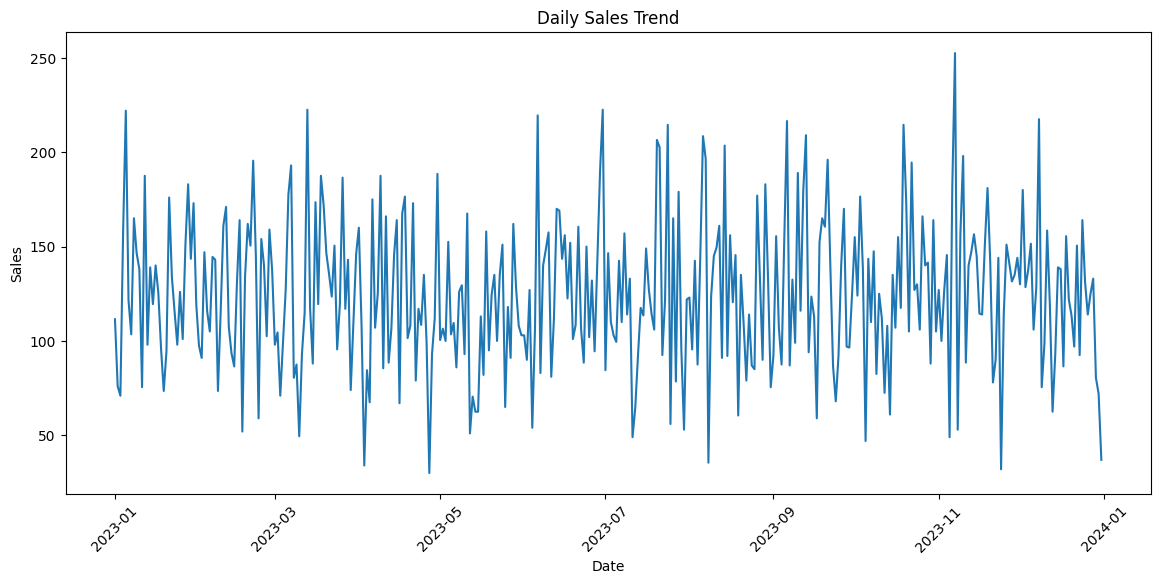

In [32]:
# Visualization of sales by product
daily_sales = df.groupby('Transaction Date')['Total Spent'].sum()

plt.figure(figsize= (14,6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.show()

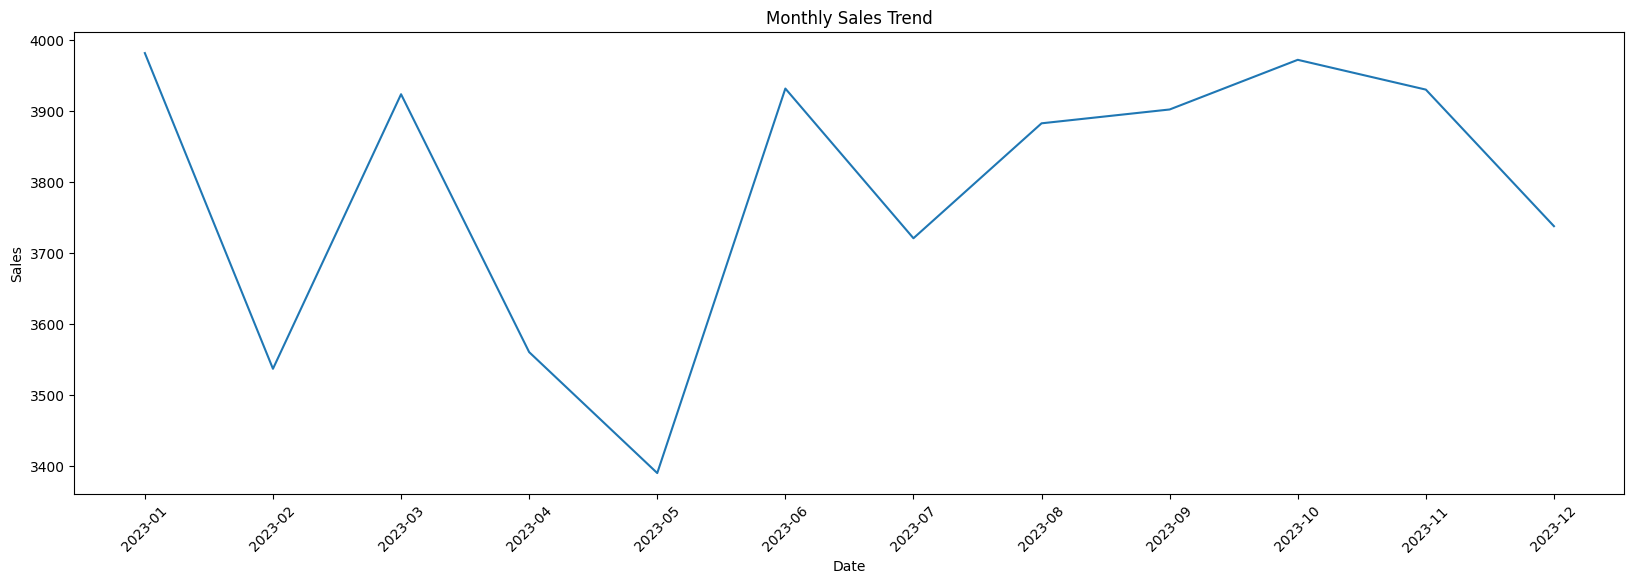

In [33]:
# Monthly sales
Monthly_sales = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].sum()

plt.figure(figsize= (20,6))
plt.plot(Monthly_sales.index.astype(str), Monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.show()

In [34]:
Monthly_sales

Transaction Date
2023-01    3982.0
2023-02    3537.0
2023-03    3924.0
2023-04    3560.5
2023-05    3390.0
2023-06    3932.0
2023-07    3721.0
2023-08    3883.0
2023-09    3902.5
2023-10    3972.5
2023-11    3930.5
2023-12    3738.0
Freq: M, Name: Total Spent, dtype: float64

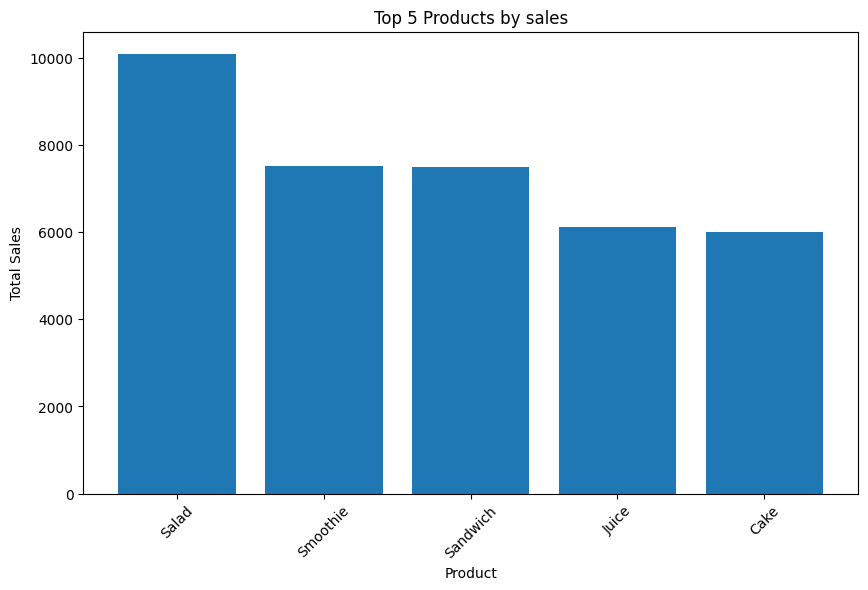

In [36]:
# Top product by sales
top_product = df.groupby('Item')['Total Spent'].sum().sort_values(ascending = False).head(5)

plt.figure(figsize=(10,6))

plt.bar(top_product.index, top_product.values)
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.title('Top 5 Products by sales')
plt.xticks(rotation = 45)
plt.show()

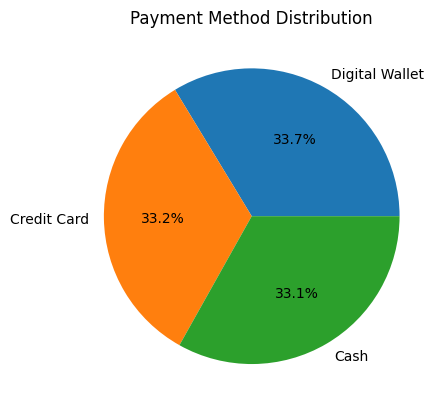

In [37]:
# Payment method distribution
payment_count = df['Payment Method'].value_counts()

plt.pie(payment_count.values, labels = payment_count.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()